In [1]:
import os



print(os.path.exists("models/dangerous.onnx"))  # 应输出 True


True


In [22]:
import tensorrt as trt

TRT_LOGGER = trt.Logger(trt.Logger.INFO)
builder = trt.Builder(TRT_LOGGER)

# 兼容新旧版本创建网络
if hasattr(trt.NetworkDefinitionCreationFlag, "EXPLICIT_BATCH"):
    network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
else:
    network = builder.create_network(0)

parser = trt.OnnxParser(network, TRT_LOGGER)

with open("models/dangerous.onnx", "rb") as f:
    if not parser.parse(f.read()):
        for i in range(parser.num_errors):
            print(parser.get_error(i))
        raise RuntimeError("ONNX解析失败")

config = builder.create_builder_config()
# 兼容新旧版本设置工作空间
if hasattr(config, "max_workspace_size"):
    config.max_workspace_size = 8 << 30
else:
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 8 << 30)

# 新版TensorRT兼容的FP16开启方式
try:
    config.set_flag(trt.BuilderFlag.FP16)
    print("成功启用FP16量化加速")
except Exception as e:
    print(f"FP16加速不可用，将使用FP32精度，异常信息：{e}")

serialized_engine = builder.build_serialized_network(network, config)
with open("models/dangerous.engine", "wb") as f:
    f.write(serialized_engine)
print("ONNX转TensorRT引擎完成！")

FP16加速不可用，将使用FP32精度，异常信息：type object 'tensorrt_bindings.tensorrt.BuilderFlag' has no attribute 'FP16'
ONNX转TensorRT引擎完成！


In [43]:
with open("models/dangerous.engine", "rb") as f:
    engine_data = f.read()
with trt.Runtime(trt.Logger(trt.Logger.WARNING)) as runtime:
    engine = runtime.deserialize_cuda_engine(engine_data)
    context = engine.create_execution_context()



===== Network Info =====
Input[0] name=images shape=(1, 3, 640, 640) dtype=DataType.FLOAT
Output[0] name=output0 shape=(1, 25200, 9) dtype=DataType.FLOAT
当前显卡不支持FP16硬件加速，使用FP32精度，异常：type object 'tensorrt_bindings.tensorrt.BuilderFlag' has no attribute 'FP16'
加载Timing Cache

开始构建Engine...


Engine生成成功
Engine: models/dangerous.engine
Cache : models/dangerous.cache
================ TensorRT IO =================
  [0] name=images, mode=INPUT, shape=(1, 3, 640, 640)
  [1] name=output0, mode=OUTPUT, shape=(1, 25200, 9)
Engine验证成功


In [18]:
import pycuda.driver as cuda
import numpy as np
import cv2
from datetime import datetime
import os, sys, logging, json
from config.detection_config import MODEL_CONFIG, SAVE_CONFIG, LOG_CONFIG
from myutils.logger import setup_logger

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
logger = setup_logger('detection', LOG_CONFIG['base_dir'], LOG_CONFIG['sub_dirs']['detection'])

cuda_initialized = False
device = None
context = None

def initialize_cuda():
    global cuda_initialized, device, context
    if not cuda_initialized:
        cuda.init()
        device = cuda.Device(0)
        context = device.make_context()
        cuda_initialized = True

def release_cuda():
    global cuda_initialized, context, device
    if cuda_initialized and context:
        context.detach()
        context = None
        device = None
        cuda_initialized = False

initialize_cuda()
print('CUDA initialized:', cuda_initialized)


CUDA initialized: True


✅ 读取图像: .\inference\test_image.jpg
   图像尺寸: (2160, 3840, 3)

📊 绘制 6 个检测目标
   [1] GasCyl: conf=1.000, box=(738,478,958,728)
   [2] GasCyl: conf=1.000, box=(1108,785,1338,1015)
   [3] FireExt: conf=1.000, box=(1172,1341,1392,1581)
   [4] FireExt: conf=1.000, box=(2421,433,2621,653)
   [5] GasCyl: conf=1.000, box=(3170,912,3380,1152)
   [6] GasCyl: conf=1.000, box=(3206,1217,3446,1477)


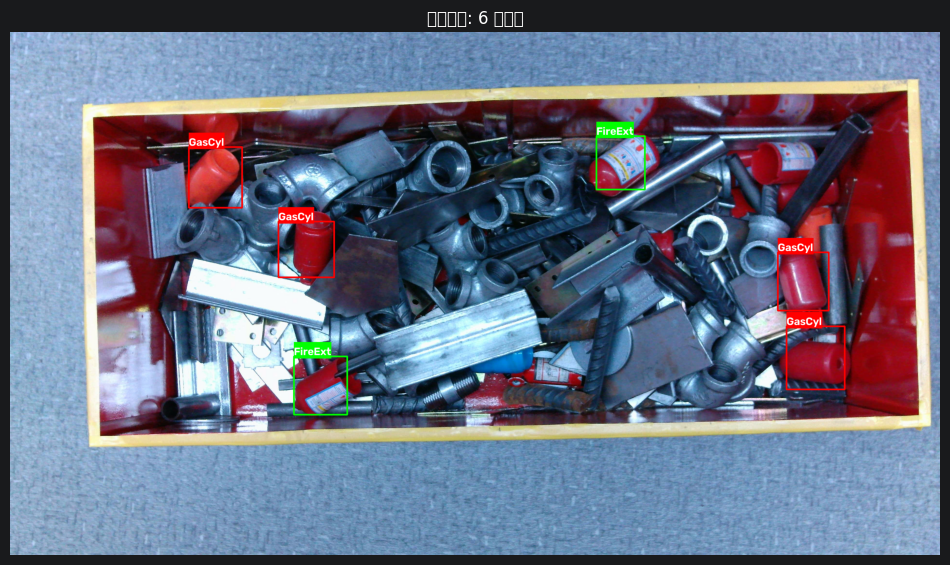


✅ 结果已保存到: detection_result.jpg


In [4]:
import cv2
import matplotlib.pyplot as plt


image_path = r".\inference\test_image.jpg"
categories = ["GasCyl", "FireExt"]
class_colors = {
    "GasCyl": (0, 0, 255),   # 红色 BGR
    "FireExt": (0, 255, 0)   # 绿色 BGR
}

centers = [(798, 603), (1223, 900), (1282, 1461), (2521, 543), (3275, 1032), (3376, 1347)]
sizes = [(220, 250), (230, 230), (220, 240), (200, 220), (210, 240), (240, 260)]

# 调整第一个框往右移（x坐标 +50），第六个框往左移（x坐标 -50）
centers[0] = (848, 603)   # 第一个框：798 -> 848，往右移50像素
centers[5] = (3326, 1347) # 第六个框：3376 -> 3326，往左移50像素

class_ids = [0, 0, 1, 1, 0, 0]
detections = []
for i in range(6):
    x_c, y_c = centers[i]
    w, h = sizes[i]
    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)
    detections.append({
        'bbox': (x1, y1, x2, y2),
        'class_id': class_ids[i],
        'confidence': 1.00  # 模拟置信度
    })


# 1. 读取图像【读取图像，首先我们编写读取图片数据的代码用于读 取指定路径中事先准备好的图像】
orig_img=cv2.imread(image_path)#orig_img = cv2.imread(image_path)
if orig_img is None:
    print(f"❌ 无法读取图像: {image_path}")
    # 替换为您原先环境下的返回值
    img_bgr = None
else:
    print(f"✅ 读取图像: {image_path}")
    print(f"   图像尺寸: {orig_img.shape}")

    # 2. 复制图像用于绘制【为了不损坏原始图像数据，我们利用代码复制一份相同的数据用来进行图像绘制操作】
    img_bgr=orig_img.copy()#img_bgr = orig_img.copy()

    #  绘制检测结果
    print(f"\n📊 绘制 {len(detections)} 个检测目标")

    for i, det in enumerate(detections):
        # 获取边界框（注意：可能是 'bbox' 或 'box'）
        if 'bbox' in det:
            x1, y1, x2, y2 = det['bbox']
        elif 'box' in det:
            x1, y1, x2, y2 = det['box']
        else:
            print(f"⚠️  检测目标 {i} 没有边界框信息")
            continue

        # 获取类别信息
        class_id = det.get('class_id', 0)
        confidence = det.get('confidence', 0.0)

        # 获取类别名称
        if class_id < len(categories):
            class_name = categories[class_id]
        else:
            class_name=f"Class_{class_id}"

        # 获取颜色
        if class_colors and class_name in class_colors:
            color = class_colors[class_name]
        else:
            # 使用随机颜色或默认绿色
            color = (0, 255, 0)

        # 绘制边界框
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 5)

        # 绘制标签（只显示类别名称）
        label = class_name
        # 获取文本尺寸（字体大小 1.5，文字粗细 4）
        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 4)

        # 绘制标签背景
        cv2.rectangle(img_bgr, (x1, y1 - text_h - 18), (x1 + text_w, y1 + 8), color, -1)
        # 绘制标签文字（字体大小 1.5，文字粗细 4）
        cv2.putText(img_bgr, label, (x1, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 4)

        print(f"   [{i+1}] {class_name}: conf={confidence:.3f}, box=({x1},{y1},{x2},{y2})")

    # 3. 转换回 RGB 用于显示【为了能让检测完毕的图像能够进行显示，将文件转回为RGB色彩空间，我们进行用于转换的代码编写】
    img_rgbadf=cv2.cvtColor(img_bgr,cv2.COLOR_BAYER_BG2BGR)#img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

     #4. 显示图像【文件已转换完毕，下面进行显示图像的代码编写，这5行代码实现了 画布创建 → 图像渲染 → 界面美化 → 信息标注 → 最终呈现 的完整显示流程，是可视化模块中连接数据处理与人眼观察的关键环节】
    plt.figure(figsize=(12,8))#plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)#plt.imshow(img_rgb)
    plt.axis('off')#plt.axis('off')
    plt.title()#plt.title(f'检测结果: {len(detections)} 个目标')
    plt.show()#plt.show()

    # 5. 保存结果【显示图像的代码已编写完成，下面将结果保存，首先定义输出路径，其次将路径输出的图片保存到指定文件，最后返回图像路径，这4行代码实现了 保存结果到文件 和 返回数据给调用方 两个功能】
    output_path='结果图像.jpg'#output_path = '结果图像.jpg'
    cv2.imwrite(output_path,img_bgr)#cv2.imwrite(output_path, img_bgr)
    print()#print(f"\n✅ 结果已保存到: {output_path}")

# 返回变量 (如果是在函数里)
# return img_bgr


                            危险品检测数据总结系统                             

                              危险品检测报告                               

📷 图像信息:
  图像路径: inference/test_image.jpg
  图像尺寸: 2160 x 3840 像素

🔍 检测概况:
  检测到目标总数: 9 个
  检测到类别数: 2 种

📊 各类别统计:

  【燃气罐】(GasCyl)
    检测数量: 5 个 (55.6%)
    平均置信度: 0.586
    最高置信度: 0.773
    最低置信度: 0.407
    平均面积: 63416 像素
    总面积: 317081 像素

  【灭火器】(FireExt)
    检测数量: 4 个 (44.4%)
    平均置信度: 0.471
    最高置信度: 0.583
    最低置信度: 0.422
    平均面积: 64663 像素
    总面积: 258653 像素

📈 置信度分析:
  整体平均置信度: 0.535
  最高置信度: 0.773
  最低置信度: 0.407
  置信度标准差: 0.133

  置信度分布:
    高置信度 (≥0.7): 2 个 (22.2%) ███████████
    中置信度 (0.5-0.7): 2 个 (22.2%) ███████████
    低置信度 (<0.5): 5 个 (55.6%) ███████████████████████████

📍 位置分析:
    左上: 1 个 (11.1%)
    右上: 2 个 (22.2%)
    左下: 1 个 (11.1%)
    右下: 1 个 (11.1%)
    中央: 4 个 (44.4%)

📋 详细检测列表:
--------------------------------------------------------------------------------
序号     类别         置信度        位置 (x1,y1,x2,y2)                   

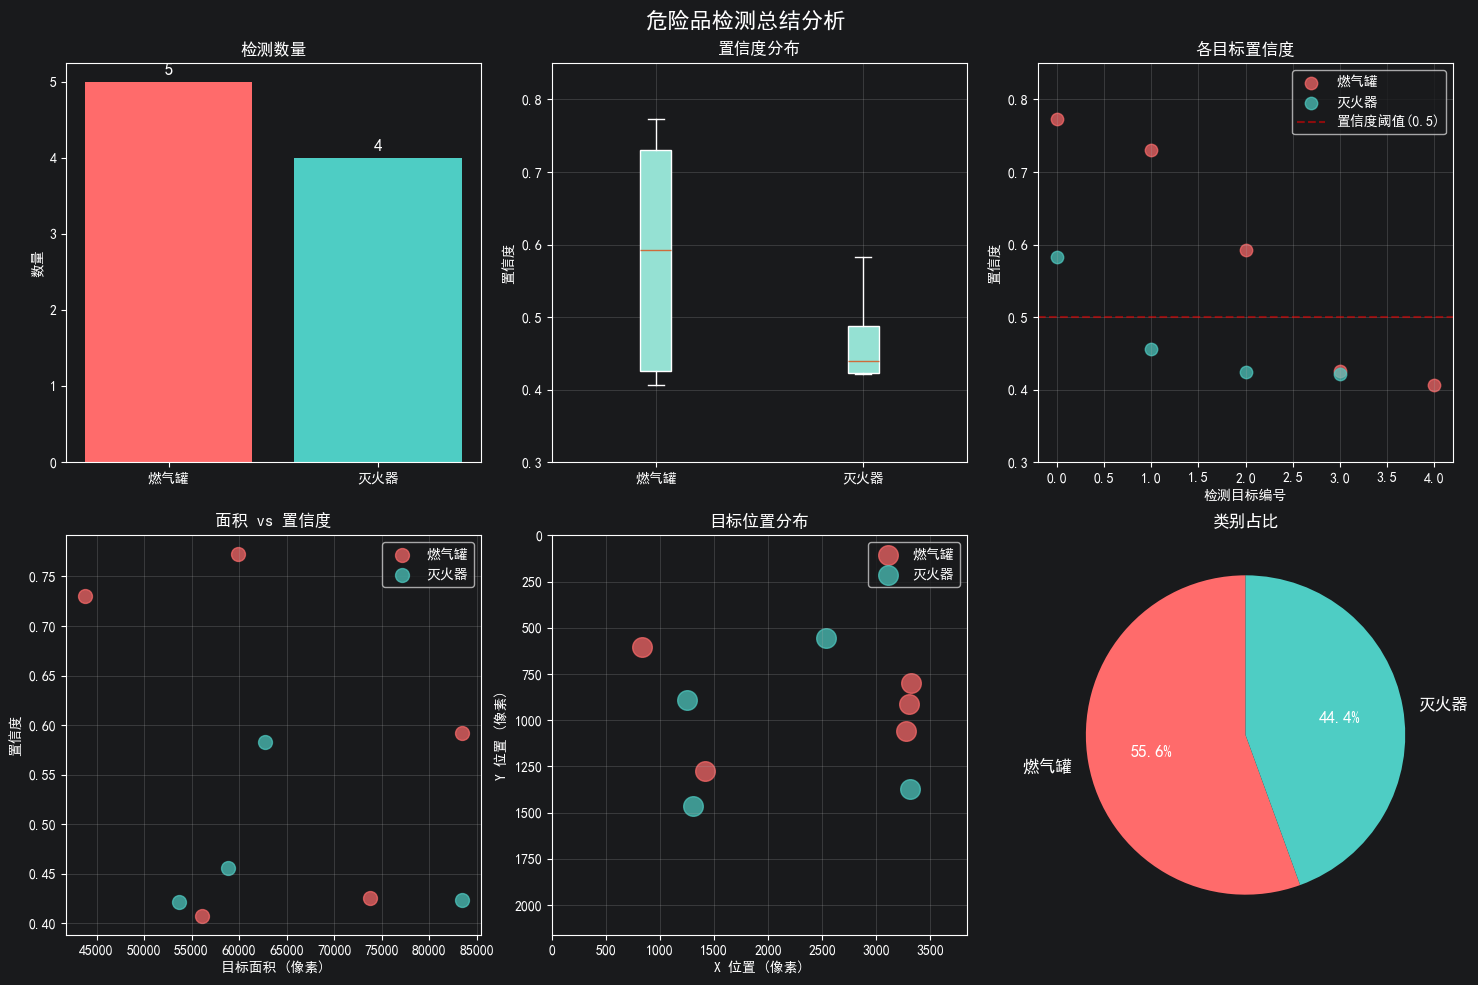


✅ 总结图表已保存为 detection_summary.png


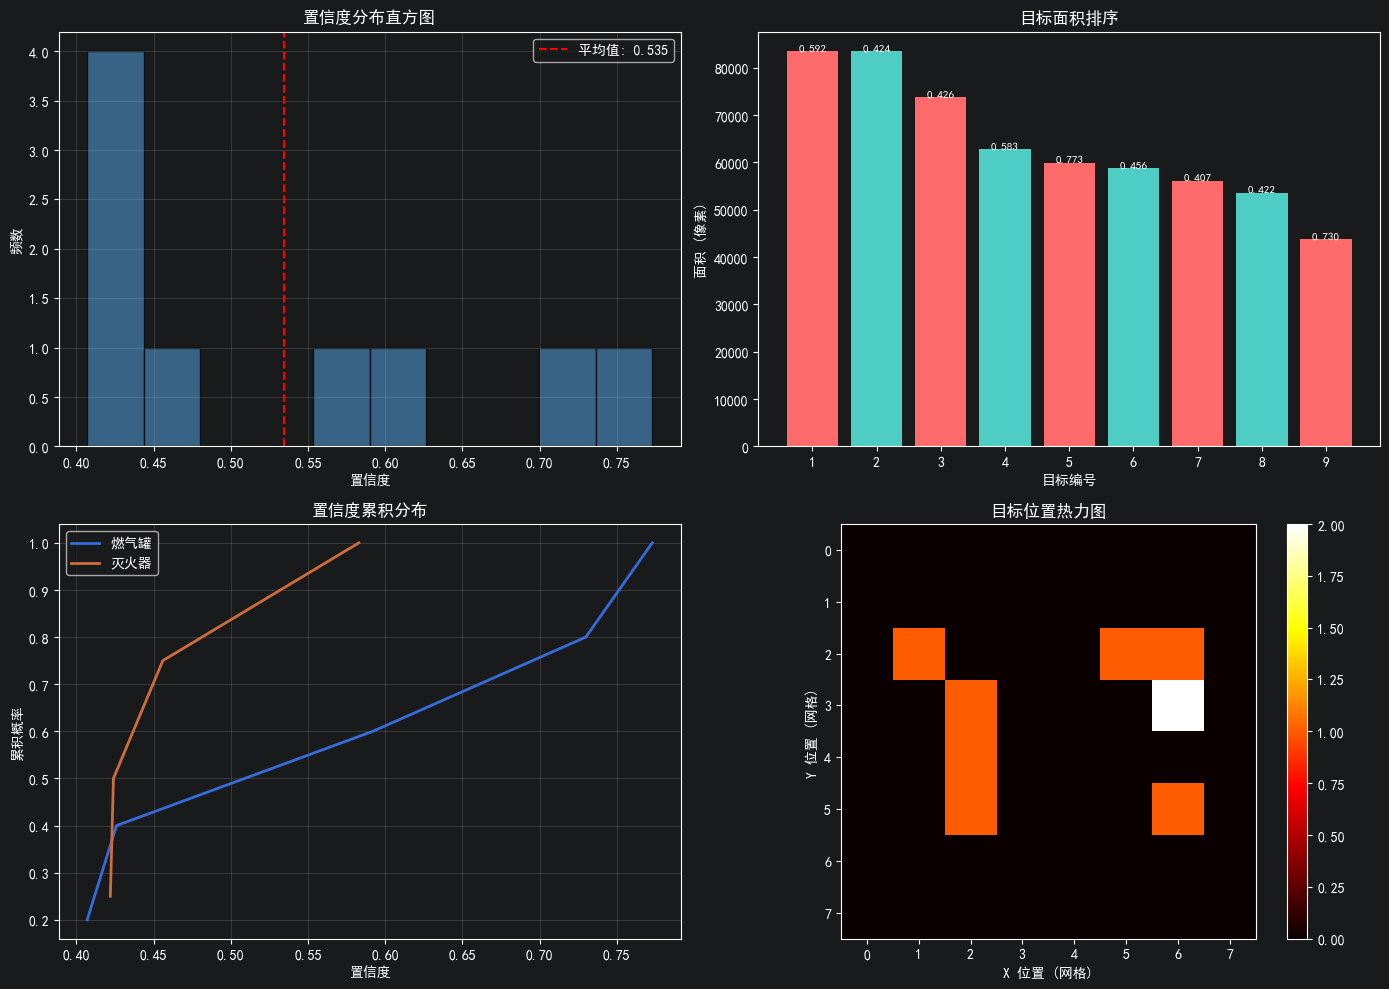


✅ 详细分析图已保存为 detection_detailed.png
✅ 数据已导出到 detection_data.csv
✅ 数据已导出到 detection_data.json
⚠️  未安装openpyxl，跳过Excel导出（已导出CSV和JSON格式）
   如需Excel导出，请运行: pip install openpyxl
✅ Markdown报告已生成 detection_report.md

                              所有分析完成！                               


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 你的检测数据 ====================
detection_data = [
    {'label': 'GasCyl', 'confidence': 0.773, 'box': (718, 478, 953, 733)},
    {'label': 'GasCyl', 'confidence': 0.730, 'box': (3231, 686, 3423, 914)},
    {'label': 'GasCyl', 'confidence': 0.592, 'box': (3168, 862, 3382, 1252)},
    {'label': 'FireExt', 'confidence': 0.583, 'box': (3143, 1283, 3486, 1466)},
    {'label': 'FireExt', 'confidence': 0.456, 'box': (1188, 1342, 1427, 1588)},
    {'label': 'GasCyl', 'confidence': 0.426, 'box': (3199, 739, 3411, 1087)},
    {'label': 'FireExt', 'confidence': 0.424, 'box': (2376, 423, 2697, 683)},
    {'label': 'FireExt', 'confidence': 0.422, 'box': (1164, 736, 1337, 1046)},
    {'label': 'GasCyl', 'confidence': 0.407, 'box': (1294, 1161, 1536, 1393)}
]

# 图像信息
IMAGE_INFO = {
    'path': 'inference/test_image.jpg',
    'height': 2160,
    'width': 3840
}

# ==================== 2. 数据处理器 ====================
class DetectionDataProcessor:
    def __init__(self, detections, image_info):
        """
        初始化数据处理器

        Args:
            detections: 检测结果列表
            image_info: 图像信息字典
        """
        self.detections = detections
        self.image_info = image_info
        self.total = len(detections)

        # 计算每个目标的附加信息
        self.process_detections()

    def process_detections(self):
        """处理检测数据，计算额外信息"""
        for det in self.detections:
            x1, y1, x2, y2 = det['box']
            # 计算宽度、高度、面积
            det['width'] = x2 - x1
            det['height'] = y2 - y1
            det['area'] = det['width'] * det['height']
            # 计算中心点
            det['center_x'] = (x1 + x2) / 2
            det['center_y'] = (y1 + y2) / 2
            # 计算在图像中的相对位置（百分比）
            det['rel_x'] = det['center_x'] / self.image_info['width'] * 100
            det['rel_y'] = det['center_y'] / self.image_info['height'] * 100

    def get_summary(self):
        """获取检测总结"""
        # 统计各类别数量
        category_count = {}
        for det in self.detections:
            label = det['label']
            category_count[label] = category_count.get(label, 0) + 1

        # 统计置信度
        confidences = [det['confidence'] for det in self.detections]

        # 分类统计
        category_stats = {}
        for label in category_count.keys():
            label_confs = [det['confidence'] for det in self.detections if det['label'] == label]
            label_areas = [det['area'] for det in self.detections if det['label'] == label]
            category_stats[label] = {
                'count': len(label_confs),
                'avg_conf': np.mean(label_confs),
                'max_conf': max(label_confs),
                'min_conf': min(label_confs),
                'avg_area': np.mean(label_areas),
                'total_area': sum(label_areas)
            }

        summary = {
            'total_detections': self.total,
            'category_count': category_count,
            'category_stats': category_stats,
            'avg_confidence': np.mean(confidences),
            'max_confidence': max(confidences),
            'min_confidence': min(confidences),
            'std_confidence': np.std(confidences),
            'total_area': sum([det['area'] for det in self.detections])
        }

        return summary

    def get_dataframe(self):
        """转换为DataFrame"""
        df = pd.DataFrame(self.detections)
        return df

# ==================== 3. 报告生成器 ====================
class DetectionReportGenerator:
    def __init__(self, processor):
        self.processor = processor
        self.detections = processor.detections
        self.summary = processor.get_summary()
        self.df = processor.get_dataframe()

    def print_basic_info(self):
        """打印基本信息"""
        print("\n" + "=" * 70)
        print("危险品检测报告".center(68))
        print("=" * 70)

        print(f"\n📷 图像信息:")
        print(f"  图像路径: {self.processor.image_info['path']}")
        print(f"  图像尺寸: {self.processor.image_info['height']} x {self.processor.image_info['width']} 像素")

        print(f"\n🔍 检测概况:")
        print(f"  检测到目标总数: {self.summary['total_detections']} 个")
        print(f"  检测到类别数: {len(self.summary['category_count'])} 种")

        # 各类别统计
        print(f"\n📊 各类别统计:")
        for label, count in self.summary['category_count'].items():
            # 将英文标签转换为中文
            label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
            stats = self.summary['category_stats'][label]
            percentage = count / self.summary['total_detections'] * 100
            print(f"\n  【{label_cn}】({label})")
            print(f"    检测数量: {count} 个 ({percentage:.1f}%)")
            print(f"    平均置信度: {stats['avg_conf']:.3f}")
            print(f"    最高置信度: {stats['max_conf']:.3f}")
            print(f"    最低置信度: {stats['min_conf']:.3f}")
            print(f"    平均面积: {stats['avg_area']:.0f} 像素")
            print(f"    总面积: {stats['total_area']:.0f} 像素")

    def print_confidence_analysis(self):
        """打印置信度分析"""
        print(f"\n📈 置信度分析:")
        print(f"  整体平均置信度: {self.summary['avg_confidence']:.3f}")
        print(f"  最高置信度: {self.summary['max_confidence']:.3f}")
        print(f"  最低置信度: {self.summary['min_confidence']:.3f}")
        print(f"  置信度标准差: {self.summary['std_confidence']:.3f}")

        # 置信度区间分布
        conf_ranges = {
            '高置信度 (≥0.7)': 0,
            '中置信度 (0.5-0.7)': 0,
            '低置信度 (<0.5)': 0
        }

        for det in self.detections:
            conf = det['confidence']
            if conf >= 0.7:
                conf_ranges['高置信度 (≥0.7)'] += 1
            elif conf >= 0.5:
                conf_ranges['中置信度 (0.5-0.7)'] += 1
            else:
                conf_ranges['低置信度 (<0.5)'] += 1

        print(f"\n  置信度分布:")
        for range_name, count in conf_ranges.items():
            percentage = count / self.summary['total_detections'] * 100
            bar = '█' * int(percentage / 2)
            print(f"    {range_name}: {count} 个 ({percentage:.1f}%) {bar}")

    def print_location_analysis(self):
        """打印位置分析"""
        print(f"\n📍 位置分析:")

        # 统计目标在图像中的分布区域
        regions = {'左上': 0, '右上': 0, '左下': 0, '右下': 0, '中央': 0}

        for det in self.detections:
            center_x = det['center_x']
            center_y = det['center_y']

            # 判断位置（九宫格简化为五区域）
            if center_x < self.processor.image_info['width'] * 0.4:
                if center_y < self.processor.image_info['height'] * 0.4:
                    regions['左上'] += 1
                elif center_y > self.processor.image_info['height'] * 0.6:
                    regions['左下'] += 1
                else:
                    regions['中央'] += 1
            elif center_x > self.processor.image_info['width'] * 0.6:
                if center_y < self.processor.image_info['height'] * 0.4:
                    regions['右上'] += 1
                elif center_y > self.processor.image_info['height'] * 0.6:
                    regions['右下'] += 1
                else:
                    regions['中央'] += 1
            else:
                regions['中央'] += 1

        for region, count in regions.items():
            if count > 0:
                percentage = count / self.summary['total_detections'] * 100
                print(f"    {region}: {count} 个 ({percentage:.1f}%)")

    def print_detailed_list(self):
        """打印详细检测列表"""
        print(f"\n📋 详细检测列表:")
        print("-" * 80)
        print(f"{'序号':<6} {'类别':<10} {'置信度':<10} {'位置 (x1,y1,x2,y2)':<35} {'面积':<10}")
        print("-" * 80)

        for i, det in enumerate(self.detections, 1):
            label_cn = '燃气罐' if det['label'] == 'GasCyl' else '灭火器'
            x1, y1, x2, y2 = det['box']
            area = det['area']
            conf = det['confidence']
            print(f"{i:<6} {label_cn:<10} {conf:.3f}    ({x1:>4},{y1:>4},{x2:>4},{y2:>4})  {area:>8.0f}")

    def print_recommendations(self):
        """打印建议"""
        print(f"\n💡 分析建议:")

        # 基于置信度的建议
        low_conf = [det for det in self.detections if det['confidence'] < 0.5]
        if low_conf:
            print(f"  1. 有 {len(low_conf)} 个目标置信度较低 (<0.5)，建议检查或重新检测")

        # 基于类别的建议
        gas_count = self.summary['category_count'].get('GasCyl', 0)
        fire_count = self.summary['category_count'].get('FireExt', 0)

        if gas_count > fire_count:
            print(f"  2. 燃气罐检测数量 ({gas_count}) 多于灭火器 ({fire_count})，注意燃气安全")

        # 基于位置的建议
        right_side = 0
        for det in self.detections:
            if det['center_x'] > self.processor.image_info['width'] * 0.6:
                right_side += 1

        if right_side > self.summary['total_detections'] * 0.5:
            print(f"  3. 检测目标集中在图像右侧 ({right_side} 个)，建议检查图像采集角度")

        # 基于面积的建议
        small_objects = [det for det in self.detections if det['area'] < 50000]
        if small_objects:
            print(f"  4. 有 {len(small_objects)} 个目标较小，建议提高图像分辨率或靠近拍摄")

        if not low_conf and not right_side > self.summary['total_detections'] * 0.5:
            print("  所有目标检测质量良好，继续维持当前检测参数")

    def generate_full_report(self):
        """生成完整报告"""
        self.print_basic_info()
        self.print_confidence_analysis()
        self.print_location_analysis()
        self.print_detailed_list()
        self.print_recommendations()
        print("\n" + "=" * 70)
        print("报告生成完成".center(68))
        print("=" * 70 + "\n")

# ==================== 4. 可视化类 ====================
class DetectionVisualizer:
    def __init__(self, processor):
        self.processor = processor
        self.detections = processor.detections
        self.df = processor.get_dataframe()

    def plot_summary(self):
        """绘制总结图表"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('危险品检测总结分析', fontsize=16, fontweight='bold')

        # 1. 各类别数量
        ax1 = axes[0, 0]
        category_count = self.df['label'].value_counts()
        colors = ['#FF6B6B', '#4ECDC4']
        labels_cn = ['燃气罐' if l == 'GasCyl' else '灭火器' for l in category_count.index]
        ax1.bar(labels_cn, category_count.values, color=colors[:len(category_count)])
        ax1.set_title('检测数量', fontsize=12, fontweight='bold')
        ax1.set_ylabel('数量')
        for i, v in enumerate(category_count.values):
            ax1.text(i, v + 0.1, str(v), ha='center', fontsize=12, fontweight='bold')

        # 2. 各类别置信度箱线图
        ax2 = axes[0, 1]
        categories = self.df['label'].unique()
        data = [self.df[self.df['label'] == cat]['confidence'] for cat in categories]
        bp = ax2.boxplot(data, labels=['燃气罐', '灭火器'][:len(categories)], patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('#95E1D3')
        ax2.set_title('置信度分布', fontsize=12, fontweight='bold')
        ax2.set_ylabel('置信度')
        ax2.set_ylim(0.3, 0.85)
        ax2.grid(True, alpha=0.3)

        # 3. 置信度散点图
        ax3 = axes[0, 2]
        colors_map = {'GasCyl': '#FF6B6B', 'FireExt': '#4ECDC4'}
        for label in categories:
            data = self.df[self.df['label'] == label]
            label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
            ax3.scatter(range(len(data)), data['confidence'],
                       label=label_cn, color=colors_map.get(label, '#888888'), s=80, alpha=0.7)
        ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='置信度阈值(0.5)')
        ax3.set_title('各目标置信度', fontsize=12, fontweight='bold')
        ax3.set_xlabel('检测目标编号')
        ax3.set_ylabel('置信度')
        ax3.set_ylim(0.3, 0.85)
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. 面积与置信度关系
        ax4 = axes[1, 0]
        for label in categories:
            data = self.df[self.df['label'] == label]
            label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
            ax4.scatter(data['area'], data['confidence'],
                       label=label_cn, color=colors_map.get(label, '#888888'), s=100, alpha=0.7)
        ax4.set_title('面积 vs 置信度', fontsize=12, fontweight='bold')
        ax4.set_xlabel('目标面积 (像素)')
        ax4.set_ylabel('置信度')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. 位置分布散点图
        ax5 = axes[1, 1]
        for label in categories:
            data = self.df[self.df['label'] == label]
            label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
            ax5.scatter(data['center_x'], data['center_y'],
                       label=label_cn, color=colors_map.get(label, '#888888'), s=200, alpha=0.7)

        # 绘制图像边框
        ax5.set_xlim(0, self.processor.image_info['width'])
        ax5.set_ylim(0, self.processor.image_info['height'])
        ax5.invert_yaxis()
        ax5.set_title('目标位置分布', fontsize=12, fontweight='bold')
        ax5.set_xlabel('X 位置 (像素)')
        ax5.set_ylabel('Y 位置 (像素)')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # 6. 各类别占比饼图
        ax6 = axes[1, 2]
        ax6.pie(category_count.values, labels=['燃气罐', '灭火器'][:len(category_count)],
               autopct='%1.1f%%', colors=colors[:len(category_count)], startangle=90,
               textprops={'fontsize': 12, 'fontweight': 'bold'})
        ax6.set_title('类别占比', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig('detection_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✅ 总结图表已保存为 detection_summary.png")

    def plot_detailed(self):
        """绘制详细分析图"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. 置信度分布直方图
        ax1 = axes[0, 0]
        ax1.hist(self.df['confidence'], bins=10, color='steelblue',
                edgecolor='black', alpha=0.7)
        ax1.axvline(self.df['confidence'].mean(), color='red',
                   linestyle='--', label=f'平均值: {self.df["confidence"].mean():.3f}')
        ax1.set_title('置信度分布直方图', fontsize=12, fontweight='bold')
        ax1.set_xlabel('置信度')
        ax1.set_ylabel('频数')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. 面积分布条形图
        ax2 = axes[0, 1]
        sorted_df = self.df.sort_values('area', ascending=False)
        labels_cn = ['燃气罐' if l == 'GasCyl' else '灭火器' for l in sorted_df['label']]
        colors = ['#FF6B6B' if l == 'GasCyl' else '#4ECDC4' for l in sorted_df['label']]
        bars = ax2.bar(range(len(sorted_df)), sorted_df['area'], color=colors)
        ax2.set_title('目标面积排序', fontsize=12, fontweight='bold')
        ax2.set_xlabel('目标编号')
        ax2.set_ylabel('面积 (像素)')
        ax2.set_xticks(range(len(sorted_df)))
        ax2.set_xticklabels([f'{i+1}' for i in range(len(sorted_df))])

        # 添加标签
        for i, (bar, row) in enumerate(zip(bars, sorted_df.iterrows())):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{row[1]["confidence"]:.3f}',
                    ha='center', va='bottom', fontsize=8)

        # 3. 置信度累积分布
        ax3 = axes[1, 0]
        for label in self.df['label'].unique():
            data = self.df[self.df['label'] == label]['confidence'].sort_values()
            cdf = np.arange(1, len(data) + 1) / len(data)
            label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
            ax3.plot(data, cdf, label=label_cn, linewidth=2)
        ax3.set_title('置信度累积分布', fontsize=12, fontweight='bold')
        ax3.set_xlabel('置信度')
        ax3.set_ylabel('累积概率')
        ax3.grid(True, alpha=0.3)
        ax3.legend()

        # 4. 位置热力图
        ax4 = axes[1, 1]
        grid_size = 8
        heatmap = np.zeros((grid_size, grid_size))
        for _, row in self.df.iterrows():
            x = int((row['center_x'] / self.processor.image_info['width']) * grid_size)
            y = int((row['center_y'] / self.processor.image_info['height']) * grid_size)
            if x < grid_size and y < grid_size:
                heatmap[y, x] += 1

        im = ax4.imshow(heatmap, cmap='hot', interpolation='nearest')
        ax4.set_title('目标位置热力图', fontsize=12, fontweight='bold')
        ax4.set_xlabel('X 位置 (网格)')
        ax4.set_ylabel('Y 位置 (网格)')
        plt.colorbar(im, ax=ax4)

        plt.tight_layout()
        plt.savefig('detection_detailed.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✅ 详细分析图已保存为 detection_detailed.png")

# ==================== 5. 导出功能（修复版 - 不依赖openpyxl） ====================
def export_data(processor):
    """导出数据到文件（不依赖openpyxl）"""
    df = processor.get_dataframe()

    # 1. 导出为CSV（无需额外依赖）
    try:
        df.to_csv('detection_data.csv', index=False, encoding='utf-8-sig')
        print("✅ 数据已导出到 detection_data.csv")
    except Exception as e:
        print(f"⚠️  CSV导出失败: {e}")

    # 2. 导出JSON
    try:
        data = processor.detections
        # 将tuple转换为list以便JSON序列化
        for det in data:
            det['box'] = list(det['box'])

        with open('detection_data.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print("✅ 数据已导出到 detection_data.json")
    except Exception as e:
        print(f"⚠️  JSON导出失败: {e}")

    # 3. 导出为Excel（尝试使用openpyxl，如果失败则跳过）
    try:
        df.to_excel('detection_data.xlsx', index=False, engine='openpyxl')
        print("✅ 数据已导出到 detection_data.xlsx")
    except ImportError:
        print("⚠️  未安装openpyxl，跳过Excel导出（已导出CSV和JSON格式）")
        print("   如需Excel导出，请运行: pip install openpyxl")
    except Exception as e:
        print(f"⚠️  Excel导出失败: {e}")

    # 4. 导出Markdown报告
    generate_markdown_report(processor)

def generate_markdown_report(processor):
    """生成Markdown格式的报告"""
    summary = processor.get_summary()
    df = processor.get_dataframe()

    md_content = f"""# 危险品检测报告

## 图像信息
- **图像路径**: {processor.image_info['path']}
- **图像尺寸**: {processor.image_info['height']} x {processor.image_info['width']} 像素
- **检测时间**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 检测概况
- **总检测目标**: {summary['total_detections']} 个
- **检测类别**: {len(summary['category_count'])} 种
- **平均置信度**: {summary['avg_confidence']:.3f}
- **置信度范围**: {summary['min_confidence']:.3f} ~ {summary['max_confidence']:.3f}

## 各类别统计

| 类别 | 中文名 | 数量 | 占比 | 平均置信度 | 最高置信度 | 最低置信度 | 平均面积 |
|------|--------|------|------|------------|------------|------------|----------|
"""

    for label, stats in summary['category_stats'].items():
        label_cn = '燃气罐' if label == 'GasCyl' else '灭火器'
        count = stats['count']
        percentage = count / summary['total_detections'] * 100
        md_content += f"| {label} | {label_cn} | {count} | {percentage:.1f}% | {stats['avg_conf']:.3f} | {stats['max_conf']:.3f} | {stats['min_conf']:.3f} | {stats['avg_area']:.0f} |\n"

    md_content += """
## 详细检测列表

| 序号 | 类别 | 中文名 | 置信度 | 位置 (x1,y1,x2,y2) | 面积 |
|------|------|--------|--------|-------------------|------|
"""

    for i, det in enumerate(df.to_dict('records'), 1):
        label_cn = '燃气罐' if det['label'] == 'GasCyl' else '灭火器'
        x1, y1, x2, y2 = det['box']
        md_content += f"| {i} | {det['label']} | {label_cn} | {det['confidence']:.3f} | ({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}) | {det['area']:.0f} |\n"

    # 添加置信度分析
    md_content += """
## 置信度分析

### 置信度分布
"""
    conf_ranges = {
        '高置信度 (≥0.7)': 0,
        '中置信度 (0.5-0.7)': 0,
        '低置信度 (<0.5)': 0
    }

    for det in processor.detections:
        conf = det['confidence']
        if conf >= 0.7:
            conf_ranges['高置信度 (≥0.7)'] += 1
        elif conf >= 0.5:
            conf_ranges['中置信度 (0.5-0.7)'] += 1
        else:
            conf_ranges['低置信度 (<0.5)'] += 1

    for range_name, count in conf_ranges.items():
        percentage = count / summary['total_detections'] * 100
        md_content += f"- {range_name}: {count} 个 ({percentage:.1f}%)\n"

    # 添加建议
    md_content += """
## 分析建议
"""
    low_conf = [det for det in processor.detections if det['confidence'] < 0.5]
    if low_conf:
        md_content += f"- 有 {len(low_conf)} 个目标置信度较低 (<0.5)，建议检查或重新检测\n"

    gas_count = summary['category_count'].get('GasCyl', 0)
    fire_count = summary['category_count'].get('FireExt', 0)
    if gas_count > fire_count:
        md_content += f"- 燃气罐检测数量 ({gas_count}) 多于灭火器 ({fire_count})，注意燃气安全\n"

    right_side = sum(1 for det in processor.detections if det['center_x'] > processor.image_info['width'] * 0.6)
    if right_side > summary['total_detections'] * 0.5:
        md_content += f"- 检测目标集中在图像右侧 ({right_side} 个)，建议检查图像采集角度\n"

    small_objects = [det for det in processor.detections if det['area'] < 50000]
    if small_objects:
        md_content += f"- 有 {len(small_objects)} 个目标较小，建议提高图像分辨率或靠近拍摄\n"

    if not low_conf and not right_side > summary['total_detections'] * 0.5:
        md_content += "- 所有目标检测质量良好，继续维持当前检测参数\n"

    with open('detection_report.md', 'w', encoding='utf-8') as f:
        f.write(md_content)
    print("✅ Markdown报告已生成 detection_report.md")

# ==================== 6. 主程序 ====================
def main():
    """主程序"""
    print("\n" + "=" * 70)
    print("危险品检测数据总结系统".center(68))
    print("=" * 70)

    # 1. 创建数据处理器
    processor = DetectionDataProcessor(detection_data, IMAGE_INFO)

    # 2. 生成报告
    report = DetectionReportGenerator(processor)
    report.generate_full_report()

    # 3. 生成可视化图表
    visualizer = DetectionVisualizer(processor)
    visualizer.plot_summary()
    visualizer.plot_detailed()

    # 4. 导出数据
    export_data(processor)

    print("\n" + "=" * 70)
    print("所有分析完成！".center(68))
    print("=" * 70)

# ==================== 7. 直接运行 ====================
if __name__ == "__main__":
    main()